In [32]:
import pandas as pd

df: pd.DataFrame = pd.read_csv(
    "data/ec2_cpu_utilization_24ae8d.csv",
    parse_dates=["timestamp"]
)

In [33]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 4032 entries, 0 to 4031
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   timestamp  4032 non-null   datetime64[us]
 1   value      4032 non-null   float64       
dtypes: datetime64[us](1), float64(1)
memory usage: 63.1 KB


## EDA

In [34]:
nulls = df.isna().sum()

duplicated_observations = df.duplicated().sum()
duplicated_timestamps = df["timestamp"].duplicated().sum()

print(f"Number of null values:\n{nulls}")
print()
print(f"Number of duplicated observations:\n{duplicated_observations}")
print()
print(f"Number of duplicated timestamps:\n{duplicated_timestamps}")

Number of null values:
timestamp    0
value        0
dtype: int64

Number of duplicated observations:
0

Number of duplicated timestamps:
0


In [35]:
df_time_index = df.set_index("timestamp", drop=True)

synthetic_series = pd.date_range(
    df_time_index.index.min(), df_time_index.index.max(), freq="5min"
)

wrong_values = df_time_index.index.difference(synthetic_series)

missing_values = synthetic_series.difference(df_time_index.index)

print(len(wrong_values))
print(len(missing_values))

0
0


### Data Quality & Integrity

A systematic verification was conducted on the time series dataset to evaluate data completeness and temporal continuity:

* **Completeness:** No missing (`NaN`) or null values were identified across the 4,032 observations.
* **Uniqueness:** There are no duplicate records or duplicate timestamps present in the dataset.
* **Temporal Regularity:** Comparing the dataset timestamps against a synthetic continuous sequence confirmed a uniform 5-minute sampling interval with zero temporal gaps or missing timestamps.

Overall, the dataset exhibits complete temporal regularity and requires no imputation or row removal before feature engineering.

### Summary Interpretation of Descriptive Statistics

An analysis of the CPU utilization statistics highlights the baseline structure of the dataset:

* **Baseline Stability:** The central metrics demonstrate concentration in a low-utilization regime. The median ($0.134$), 75th percentile ($0.134$), and 90th percentile ($0.134$) are identical. Furthermore, $96\%$ of all measurements remain at or below $0.1375$, indicating that the server operates within a narrow band for the vast majority of the time.
* **Tail Distribution:** The large difference between the 96th and 96.1st percentiles indicates a increase in the upper tail of the CPU utilization distribution.
* **Implication for Modeling:** 
  * Because $96\%$ of the data points are confined below $0.1375$, small absolute increases above this threshold mark a clear transition away from baseline behavior.
  * The steep upper tail confirms severe right-skewness, making tree-based isolation methods like Isolation Forest suitable for partitioning these sparse, high-value observations without assuming a Gaussian distribution.

In [36]:
descritive_measures = df["value"].describe()

descritive_measures.loc["90%"] = df["value"].quantile(0.90)
descritive_measures.loc["95%"] = df["value"].quantile(0.95)
descritive_measures.loc["96%"] = df["value"].quantile(0.96)
descritive_measures.loc["96,1%"] = df["value"].quantile(0.961)

descritive_measures

count    4032.000000
mean        0.126303
std         0.094813
min         0.066000
25%         0.132000
50%         0.134000
75%         0.134000
max         2.344000
90%         0.134000
95%         0.136000
96%         0.137520
96,1%       0.196000
Name: value, dtype: float64

In [ ]:
from pathlib import Path
from datetime import datetime
import json

def extract_labels(file_path: Path | str):

    with open(file_path, "r", encoding="utf-8") as file:
        labels_json: dict[str, list[str]] = json.load(file)

    labels: list[datetime] = [
        datetime.strptime(l, "%Y-%m-%d %H:%M:%S") for l in labels_json["realAWSCloudwatch/ec2_cpu_utilization_24ae8d.csv"]
    ]
    return labels

labels_path: Path = Path().cwd() / "data" / "combined_labels.json"
labels = extract_labels(labels_path)
labels

[datetime.datetime(2014, 2, 26, 22, 5), datetime.datetime(2014, 2, 27, 17, 15)]

In [38]:
import numpy as np

df["is_anomaly"] = np.where(df["timestamp"].isin(labels), 1, 0)

In [39]:
df[df["is_anomaly"] == 1]

,timestamp,value,is_anomaly
3547,2014-02-26 22:05:00,2.344,1
3777,2014-02-27 17:15:00,0.602,1


#### Analysis of Unlabeled CPU Spikes

Observing the time series visualization reveals periodic spikes reaching CPU utilization levels between ~1.4 and ~1.6 throughout the 14-day window. However, only two specific events are annotated as true anomalies in the ground truth:

1. **True Anomaly Criteria:** The labeled anomalies correspond to distinct structural deviations from this pattern:
   * The **first labeled point** (~2.34 on 2014-02-26) corresponds to an extreme, unprecedented magnitude spike that significantly exceeds the routine daily spikes.
   * The **second labeled point** (~0.60 on 2014-02-27) represents an unexpected out-of-schedule rise during a period where baseline consumption is usually low (~0.134), failing to match the expected periodic cycle.
2. **Modeling Challenge:** Unsupervised models, like Isolation Forest, or simple thresholding techniques, like Z-score, may flag the regular daily spikes as false positives due to their high magnitude. Engineering temporal features, such as hour of day or rolling statistics, will may be able to help models distinguish between expected periodic bursts and genuine anomalies.

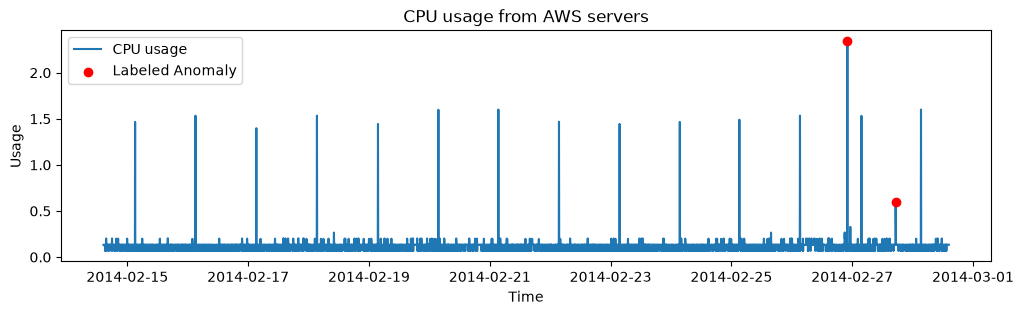

In [40]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 3))
plt.title("CPU usage from AWS servers")
plt.xlabel("Time")
plt.ylabel("Usage")
plt.plot(df["timestamp"], df["value"], label="CPU usage")
plt.scatter(
    x=df[df["is_anomaly"] == 1]["timestamp"], 
    y=df[df["is_anomaly"]== 1]["value"],
    c="red",
    zorder=2,
    label="Labeled Anomaly"
)
plt.legend()

#### Discarding the Histogram Plot
The global histogram was omitted from the analysis due to the high concentration of observations around the baseline CPU utilization and the presence of extreme values. The interquartile range (0.132–0.134) indicates that the central 50% of observations are concentrated within a narrow interval, while occasional peaks reach up to 2.344.

This difference in scale makes it difficult to visualize the central distribution and extreme values simultaneously using a standard histogram. Therefore, time series line plots and rolling feature analysis were prioritized to better capture temporal dynamics and identify potential anomaly events.


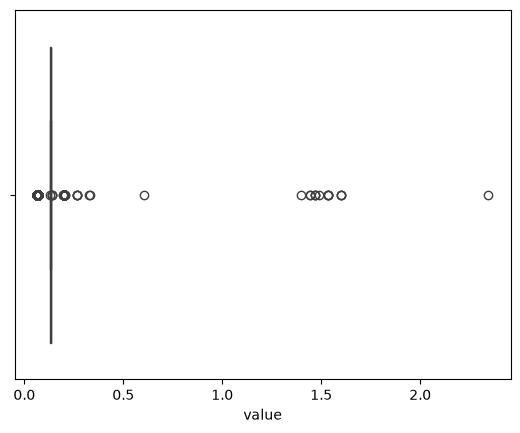

In [41]:
import seaborn as sns

sns.boxplot(
    data=df,
    x="value"
)

plt.show()

In [42]:
bins = [-np.inf, 0.14, 0.2, 0.4, 1, 2, np.inf]

cpu_interval_labels  = [
    "< 0.14",
    "0.14 - 0.2",
    "0.2 - 0.4",
    "0.4 - 1",
    "1 - 2",
    ">= 2"
]

cpu_intervals = pd.cut(
    df["value"],
    bins=bins,
    labels=cpu_interval_labels,
    right=False
)

intervals = (
    cpu_intervals
    .value_counts(sort=False)
    .rename_axis("interval")
    .reset_index(name="observations")
)

intervals

,interval,observations
0,< 0.14,3872
1,0.14 - 0.2,37
2,0.2 - 0.4,107
3,0.4 - 1,1
4,1 - 2,14
5,>= 2,1


<BarContainer object of 6 artists>

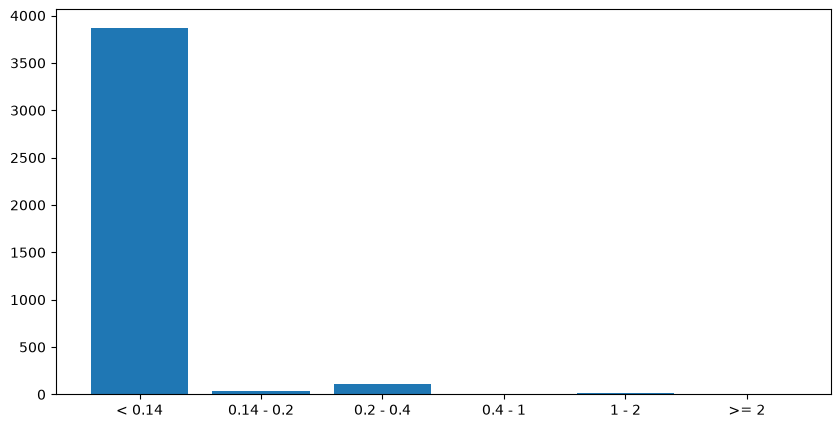

In [43]:
ax = plt.figure(figsize=(10, 5))
plt.bar(intervals["interval"], intervals["observations"])

In [44]:
high_cpu = df[df["value"] > 1].copy()

high_cpu["hour"] = high_cpu["timestamp"].dt.hour

high_cpu["hour"].value_counts().sort_index()

hour
3     14
22     1
Name: count, dtype: int64

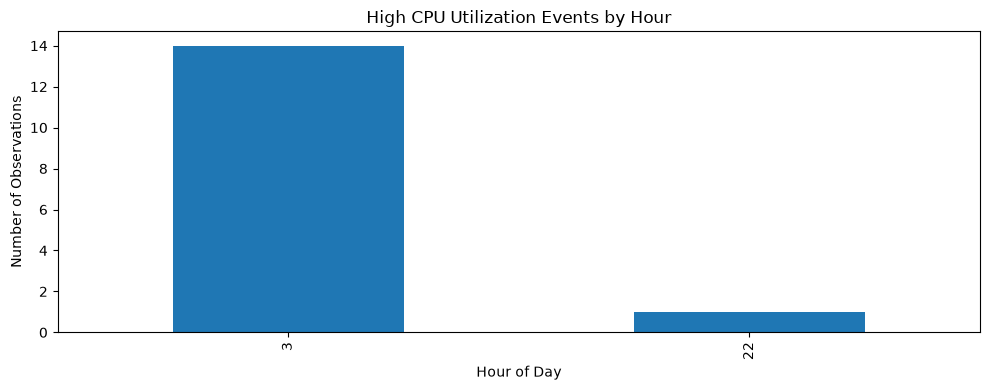

In [45]:
high_cpu["hour"].value_counts().sort_index().plot(
    kind="bar",
    figsize=(10, 4)
)

plt.title("High CPU Utilization Events by Hour")
plt.xlabel("Hour of Day")
plt.ylabel("Number of Observations")
plt.tight_layout()
plt.show()

## Rolling Z-Score

#### Feature creation for Rolling Z-Score

To compute a localized Z-score, two rolling features are engineered across a moving window:

$$Z_t = \frac{x_t - \mu_{W, t}}{\sigma_{W, t}}$$

* **`rolling_mean_12` ($\mu_{W, t}$)**: Calculates the moving average of the CPU utilization over a window of 12 prior observations.
* **`rolling_std_12` ($\sigma_{W, t}$)**: Calculates the rolling standard deviation over the same 12-period window.

To prevent data leakage during online detection, a `.shift(1)` transformation is applied. This ensures that the baseline statistics ($\mu_{W, t}$ and $\sigma_{W, t}$) for evaluating the observation at time $t$ are derived exclusively from historical data ($t-1$ to $t-12$), excluding the current value $x_t$ itself.

The window size of 12 periods, representing 60 minutes of historical data at 5-minute sampling intervals, was selected as an arbitrary initial baseline without prior optimization.

In [46]:
df["rolling_mean_12"] = df["value"].shift(1).rolling(12).mean()
df["rolling_std_12"] = df["value"].shift(1).rolling(12).std()

#### Handling missing values from feature creation
A dropna() was applied to remove the first 12 rows of the dataset. These NaN values were naturally introduced by the rolling window calculations (e.g., 12-period moving averages and standard deviations). 

Since 12 observations represent less than 0.3% of the total dataset and contain no labeled anomaly events, dropping them has no impact on model evaluation or temporal continuity.

In [47]:
df = df.dropna().reset_index(drop=True)

In [48]:
df[df["is_anomaly"] == 1]

,timestamp,value,is_anomaly,rolling_mean_12,rolling_std_12
3535,2014-02-26 22:05:00,2.344,1,0.143833,0.055146
3765,2014-02-27 17:15:00,0.602,1,0.128167,0.019604


#### Baseline Rolling Z-Score evaluation & observations

Evaluating the top 25 observations with the highest `rolling_z_score` values representing approximately the top ~0.6% most anomalous points out of the 4,032 records:

1. **Detection of Labeled Anomalies**: The simple rolling Z-score successfully places both ground-truth anomalies within the top 25 records.

2. **Sensitivity to Low Rolling Variance**: Several unannotated points yield higher Z-scores than the true anomalies, like a score of $\approx 86.92$. This occurs because the baseline CPU utilization fluctuates within narrow bands ($\sigma_{W,t} \approx 0.0007$ to $0.001$). Minor absolute shifts, such as dropping from $0.134$ to $0.066$, cause a near-zero standard deviation denominator, resulting in artificially inflated Z-scores.

3. **Lack of Seasonality Awareness**: The Z-score evaluates variations only within a short 60-minute window, ignoring the seasonality. As a result, it treats routine daily CPU spikes of ~1.4–1.6 as anomalies simply because they differ from the immediate past hour, producing high Z-scores $\approx 40$–$51$.

In [49]:
df["rolling_z_score"] = abs(
    (df["value"] - df["rolling_mean_12"]) / df["rolling_std_12"]
)

top_25_z_score = df.nlargest(25, "rolling_z_score")

top_25_z_score

,timestamp,value,is_anomaly,rolling_mean_12,rolling_std_12,rolling_z_score
3205,2014-02-25 18:35:00,0.066,0,0.133667,0.000778,86.919407
1484,2014-02-19 19:10:00,0.202,0,0.133333,0.000985,69.731330
3779,2014-02-27 18:25:00,0.066,0,0.133333,0.000985,68.377323
3339,2014-02-26 05:45:00,0.202,0,0.132833,0.001030,67.161408
3377,2014-02-26 08:55:00,0.202,0,0.133000,0.001044,66.062470
1228,2014-02-18 21:50:00,0.068,0,0.133833,0.001030,63.924714
1790,2014-02-20 20:40:00,0.066,0,0.133667,0.001155,58.601052
3020,2014-02-25 03:10:00,1.490,0,0.122500,0.026411,51.777500
1726,2014-02-20 15:20:00,0.066,0,0.133333,0.001303,51.688398
3432,2014-02-26 13:30:00,0.066,0,0.133333,0.001303,51.688398


#### Threshold Analysis

Testing fixed Z-score thresholds illustrates the sensitivity of simple statistical rules on this dataset:

* **High false positive rate at standard cutoffs**: The typical threshold of $\text{Z-score} > 3.0$ triggers 100 anomaly alerts, which is ~2.5% of the dataset.
* **Rapid decay**: Increasing the threshold from $3.0$ to $3.25$ drops the flag count by over 50%, from 100 to 47, showing how tightly clustered many noise-driven Z-scores are around the $3.0$ boundary.
* **High thresholds**: Even at a severe cutoff of $\text{Z-score} > 7.0$, 25 anomalies are flagged. As seen in the top 25 analysis, this threshold will detect the 2 real ground-truth anomalies but it's very high considering the standards for this evaluations.

In [50]:
thresholds = [3.0, 3.25, 3.5, 4, 7]

for threshold in thresholds:
    pred_z_score = df[df["rolling_z_score"] > threshold]
    print(f"Number of anomalies with threshold {threshold}:\n{pred_z_score.shape[0]}")

Number of anomalies with threshold 3.0:
100
Number of anomalies with threshold 3.25:
47
Number of anomalies with threshold 3.5:
40
Number of anomalies with threshold 4:
28
Number of anomalies with threshold 7:
25


#### Sensitivity Analysis of Regularized (Smoothed) Rolling Z-Score

To resolve the division-by-near-zero variance issue, a smoothing parameter $\epsilon$ (`smooth_value`) was introduced to the denominator:

$$Z_{\text{smooth}} = \frac{\vert{}x_t - \mu_{W, t}\vert{}}{\sigma_{W, t} + \epsilon}$$



In [51]:
smooth_values = [0.001, 0.005, 0.01, 0.05, 0.1, 0.15, 0.2]
summary_data = []

for sv in smooth_values:
    df[f"rolling_smooth_z_score"] = abs(
            (df["value"] - df["rolling_mean_12"]) / (df["rolling_std_12"] + sv)
        )
    
    top_25 = df.nlargest(25, f"rolling_smooth_z_score")
    top_25["rank"] = top_25["rolling_smooth_z_score"].rank(ascending=False)

    data = {
        f"smooth_value": sv,
        f"min_z_score": top_25[f"rolling_smooth_z_score"].min(),
        f"max_z_score": top_25[f"rolling_smooth_z_score"].max(),
        f"2.34_anomaly_pos": top_25.loc[top_25.index == 3535, "rank"].item(),
        f"2.34_anomaly_z": top_25.loc[top_25.index == 3535, "rolling_smooth_z_score"].item(),
        f"0.6_anomaly_pos": top_25.loc[top_25.index == 3765, "rank"].item(),
        f"0.6_anomaly_z": top_25.loc[top_25.index == 3765, "rolling_smooth_z_score"].item()
    }

    summary_data.append(data)

pd.DataFrame(summary_data)

,smooth_value,min_z_score,max_z_score,2.34_anomaly_pos,2.34_anomaly_z,0.6_anomaly_pos,0.6_anomaly_z
0,0.001,22.996682,49.888575,13.0,39.186657,25.0,22.996682
1,0.005,10.683290,43.535585,10.0,36.580546,16.0,19.258056
2,0.010,5.957290,37.557243,8.0,33.772956,16.0,16.005492
3,0.050,1.322785,20.924910,1.0,20.924910,16.0,6.807518
4,0.100,0.684616,14.181283,1.0,14.181283,16.0,3.961671
5,0.150,0.489403,10.724892,1.0,10.724892,16.0,2.793756
6,0.200,0.384325,8.623174,1.0,8.623174,16.0,2.157668


Evaluating a spectrum of $\epsilon$ values from $0.001$ to $0.200$ reveals clear trade-offs between noise suppression and signal attenuation.

1. **Under-Smoothing ($\epsilon < 0.05$)**: For lower values such as $0.001$ or $0.010$, standard deviation noise still exerts influence. Although the rank of the main anomaly improves, division artifacts continue to produce inflated scores where max z score values were exceeding $37$.
2. **Optimal Trade-Off Zone ($\epsilon = 0.05$ to $0.10$)**:
   * At the thresholding $Z > 3.0$ both $\epsilon = 0.05$ and $\epsilon = 0.10$ filter out most noise, each flagging exactly 16 points (~0.4% of the dataset). A significant reduction from the 100 alerts generated by the unregularized Z-score.
   * At $\epsilon = 0.05$, the severe anomaly ($2.34$) achieves rank 1 ($Z \approx 20.92$), while the subtle anomaly ($0.60$) maintains a prominent score of $Z \approx 6.81$ (rank 16). At $\epsilon = 0.10$, total score scale stabilizes further. $2.34$ remains ranked 1st ($Z \approx 14.18$), and $0.60$ retains $Z \approx 3.96$, keeping it above alerting cutoffs.
   
3. **Over-Smoothing ($\epsilon > 0.10$)**: Higher parameters ($\epsilon \ge 0.15$) excessively damp relative signal magnitude. For instance, at $\epsilon = 0.15$, the subtle anomaly score drops to $2.79$, falling below standard alerting cutoffs.

**Conclusion**: Either $0.05$ and $0.1$ will work, choosing will depends on the approach for the less false positives or more room to find errors trade off.

In [52]:
df[f"rolling_smooth_z_score_0.05"] = abs(
            (df["value"] - df["rolling_mean_12"]) / (df["rolling_std_12"] + 0.05)
        )

df[f"rolling_smooth_z_score_0.1"] = abs(
            (df["value"] - df["rolling_mean_12"]) / (df["rolling_std_12"] + 0.1)
        )

print(f"Number of detections of sv = 0.05:\n{df[df["rolling_smooth_z_score_0.05"] > 3].shape[0]}")
print(f"Number of detections of sv = 0.1:\n{df[df["rolling_smooth_z_score_0.1"] > 3].shape[0]}")

Number of detections of sv = 0.05:
16
Number of detections of sv = 0.1:
16


#### Conclusion on Rolling Z-Score Baseline

The smoothed rolling Z-score demonstrates that a localized statistical threshold can successfully isolate severe univariate anomalies while filtering out micro-variance noise. By selecting an appropriate smoothing parameter, the model detects both ground-truth anomalies within a manageable set of 16 flags ($Z > 3.0$), making it an efficient, low-overhead baseline. However, its primary limitation remains its short memory horizon: evaluating metrics purely within a local 60-minute window leaves the model unaware of global daily seasonality, causing expected periodic CPU spikes to trigger false positives simply because they deviate from immediate past behavior.

## Isolation Forest

In [170]:
df: pd.DataFrame = pd.read_csv(
    "data/ec2_cpu_utilization_24ae8d.csv",
    parse_dates=["timestamp"]
)

labels_path: Path = Path().cwd() / "data" / "combined_labels.json"
labels = extract_labels(labels_path)
df["is_anomaly"] = np.where(df["timestamp"].isin(labels), 1, 0)

df.head()


,timestamp,value,is_anomaly
0,2014-02-14 14:30:00,0.132,0
1,2014-02-14 14:35:00,0.134,0
2,2014-02-14 14:40:00,0.134,0
3,2014-02-14 14:45:00,0.134,0
4,2014-02-14 14:50:00,0.134,0


In [171]:
df[df["is_anomaly"] == 1]

,timestamp,value,is_anomaly
3547,2014-02-26 22:05:00,2.344,1
3777,2014-02-27 17:15:00,0.602,1


In [172]:
from sklearn.ensemble import IsolationForest
from sklearn.metrics import classification_report, confusion_matrix

iso_forest = IsolationForest(
    contamination=0.005,
    random_state=1
)

X = df[['value']]

y = df["is_anomaly"]

pred = iso_forest.fit_predict(X)
y_pred = [1 if x == -1 else 0 for x in pred]


print(f"\n--- Results Isolation Forest ---")
print("\nConfusion Matrix X:")
print()
print(confusion_matrix(y, y_pred))

print("\nClassification Report X:")
print(classification_report(y, y_pred, target_names=['Normal (0)', 'Anomaly (1)']))



--- Results Isolation Forest ---

Confusion Matrix X:

[[4014   16]
 [   0    2]]

Classification Report X:
              precision    recall  f1-score   support

  Normal (0)       1.00      1.00      1.00      4030
 Anomaly (1)       0.11      1.00      0.20         2

    accuracy                           1.00      4032
   macro avg       0.56      1.00      0.60      4032
weighted avg       1.00      1.00      1.00      4032



In [173]:
df["hour"] = df["timestamp"].dt.hour

df["hour_sin"] = np.sin(
    2 * np.pi * df["hour"] / 24
)

df["hour_cos"] = np.cos(
    2 * np.pi * df["hour"] / 24
)

In [174]:
df["hour_mean"] = (
    df.groupby("hour")["value"]
      .transform("mean")
)

df["hour_median"] = (
    df.groupby("hour")["value"]
      .transform("median")
)

In [175]:
df["hour_q95"] = (
    df.groupby("hour")["value"]
      .transform(lambda x: x.quantile(0.95))
)

df["dist_95qt"] = (
    df["value"] - df["hour_q95"]
)

In [179]:
X_hour = df[
    ["value", "hour"]
]

X_cyclical = df[
    ["value", "hour_sin", "hour_cos"]
]

X_descritive = df[
    ["value", "hour_mean", "hour_median"]
]

X_dist_95qt = df[
    ["dist_95qt"]
]

In [180]:
# IF Hour

if_hour = IsolationForest(
    random_state=1
)
if_hour.fit(X_hour)
df["if_anomaly_score_hour"] = if_hour.decision_function(X_hour)

# IF Cyclical

if_cyclical = IsolationForest(
    random_state=1
)
if_cyclical.fit(X_cyclical)
df["if_anomaly_score_cyclical"] = if_cyclical.decision_function(X_cyclical)

# IF descritive statistics

if_descritive = IsolationForest(
    random_state=1
)
if_descritive.fit(X_descritive)
df["if_anomaly_score_descritive"] = if_descritive.decision_function(X_descritive)

# IF distance from 95th quantile

if_dist_95qt = IsolationForest(
    random_state=1
)
if_dist_95qt.fit(X_dist_95qt)
df["if_anomaly_score_dist95qt"] = if_dist_95qt.decision_function(X_dist_95qt)

In [ ]:
rank_hour = df.nsmallest(25,"if_anomaly_score_hour")[
    [
        "timestamp",
        "value",
        "hour",
        "is_anomaly",
        "if_anomaly_score_hour"
    ]
].rank()

In [185]:
df["if_anomaly_score_value"] = iso_forest.decision_function(X)

score_columns = [col for col in df.columns if col.startswith("if_anomaly_score_")]

anomaly_positions = np.where(df["is_anomaly"].to_numpy() == 1)[0]
anomaly_234 = int(anomaly_positions[np.argmax(df.iloc[anomaly_positions]["value"].to_numpy())])
anomaly_06 = int(anomaly_positions[np.argmin(df.iloc[anomaly_positions]["value"].to_numpy())])

summary_data = []

for col in score_columns:
    rank = df[col].rank(ascending=True, method="min")

    summary_data.append({
        "model": col.replace("if_anomaly_score_", ""),
        "2.34_anomaly_pos": int(rank.iloc[anomaly_234]),
        "2.34_anomaly_score": df[col].iloc[anomaly_234],
        "0.6_anomaly_pos": int(rank.iloc[anomaly_06]),
        "0.6_anomaly_score": df[col].iloc[anomaly_06]
    })

pd.DataFrame(summary_data)

,model,2.34_anomaly_pos,2.34_anomaly_score,0.6_anomaly_pos,0.6_anomaly_score
0,hour,15,-0.274667,17,-0.196227
1,cyclical,15,-0.219188,16,-0.188044
2,descritive,15,-0.241812,113,-0.179616
3,dist95qt,41,-0.241781,42,-0.240277
4,value,1,-0.125183,16,-0.044812


#### Conclusion on Isolation Forest tests
The Isolation Forest model was able to detect the labeled anomalies with performance comparable to the regularized Rolling Z-Score. However, the tested temporal and seasonal feature-engineering strategies did not enable the model to reliably distinguish recurring daily CPU spikes from true anomalous events.